# Reconstruction Baselines

This notebook is the first reconstruction stage. It compares classical baselines for estimating the clean galaxy image `x` from the degraded observation `y` generated in notebook 03.

The goal is not to beat every method yet. The goal is to establish interpretable reference points before adding a learned model.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image

from galaxy_zoo_project.degradation import load_rgb_float
from galaxy_zoo_project.reconstruction import ReconstructionConfig, build_reconstruction_dataset

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DEGRADED_DIR = PROJECT_ROOT / "data" / "degraded" / "galaxy_zoo_128_moderate"
DEGRADED_MANIFEST_PATH = DEGRADED_DIR / "manifest.csv"
RECONSTRUCTED_DIR = PROJECT_ROOT / "data" / "reconstructed" / "galaxy_zoo_128_baselines"

PROJECT_ROOT, DEGRADED_MANIFEST_PATH, RECONSTRUCTED_DIR


/home/vm/dev/Project (Computational Imaging + Physics Applications of AI)/galaxy-zoo-project/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(PosixPath('/home/vm/dev/Project (Computational Imaging + Physics Applications of AI)/galaxy-zoo-project'),
 PosixPath('/home/vm/dev/Project (Computational Imaging + Physics Applications of AI)/galaxy-zoo-project/data/degraded/galaxy_zoo_128_moderate/manifest.csv'),
 PosixPath('/home/vm/dev/Project (Computational Imaging + Physics Applications of AI)/galaxy-zoo-project/data/reconstructed/galaxy_zoo_128_baselines'))

## Configure Baselines

The methods here are deliberately simple:

- `identity`: no reconstruction, just the degraded input
- `gaussian_smooth`: denoise by low-pass filtering
- `tv_denoise`: total-variation denoising
- `richardson_lucy`: iterative deconvolution using a Gaussian PSF estimate


In [2]:
RECONSTRUCTION_LIMIT = 32  # Set to None to run all degraded images.
METHODS = ("identity", "gaussian_smooth", "tv_denoise", "richardson_lucy")
OVERWRITE = True

config = ReconstructionConfig(
    project_root=PROJECT_ROOT,
    degraded_manifest_path=DEGRADED_MANIFEST_PATH,
    output_dir=RECONSTRUCTED_DIR,
    methods=METHODS,
    limit=RECONSTRUCTION_LIMIT,
    smooth_sigma=0.6,
    tv_weight=0.06,
    rl_sigma=1.2,
    rl_iterations=12,
    overwrite=OVERWRITE,
)

config


ReconstructionConfig(project_root=PosixPath('/home/vm/dev/Project (Computational Imaging + Physics Applications of AI)/galaxy-zoo-project'), degraded_manifest_path=PosixPath('/home/vm/dev/Project (Computational Imaging + Physics Applications of AI)/galaxy-zoo-project/data/degraded/galaxy_zoo_128_moderate/manifest.csv'), output_dir=PosixPath('/home/vm/dev/Project (Computational Imaging + Physics Applications of AI)/galaxy-zoo-project/data/reconstructed/galaxy_zoo_128_baselines'), methods=('identity', 'gaussian_smooth', 'tv_denoise', 'richardson_lucy'), limit=32, smooth_sigma=0.6, tv_weight=0.06, unsharp_radius=1.0, unsharp_amount=1.2, rl_sigma=1.2, rl_iterations=12, overwrite=True)

## Run Reconstruction Baselines

This writes one reconstructed image per method and galaxy, plus a manifest containing PSNR/SSIM against the clean processed image.


In [3]:
reconstruction_manifest = build_reconstruction_dataset(config)

print(f"Method-image pairs: {len(reconstruction_manifest):,}")
print(f"Manifest: {(RECONSTRUCTED_DIR / 'manifest.csv').relative_to(PROJECT_ROOT)}")


Reconstructing images:   0%|          | 0/32 [00:00<?, ?image/s]

Reconstructing images:   6%|▋         | 2/32 [00:00<00:02, 13.11image/s]

Reconstructing images:  12%|█▎        | 4/32 [00:00<00:01, 14.53image/s]

Reconstructing images:  19%|█▉        | 6/32 [00:00<00:01, 13.21image/s]

Reconstructing images:  25%|██▌       | 8/32 [00:00<00:01, 14.36image/s]

...

Reconstructing images:  88%|████████▊ | 28/32 [00:01<00:00, 14.64image/s]

Reconstructing images:  94%|█████████▍| 30/32 [00:02<00:00, 15.13image/s]

Reconstructing images: 100%|██████████| 32/32 [00:02<00:00, 15.43image/s]

Reconstructing images: 100%|██████████| 32/32 [00:02<00:00, 14.90image/s]

Method-image pairs: 128
Manifest: data/reconstructed/galaxy_zoo_128_baselines/manifest.csv


## Compare Metrics

Higher PSNR and SSIM are better. The `identity` row is the degraded observation itself, so every useful reconstruction method should be compared against that baseline.


In [4]:
reconstruction_manifest = pd.read_csv(RECONSTRUCTED_DIR / "manifest.csv")

metric_summary = (
    reconstruction_manifest
    .groupby("method")[["psnr", "ssim"]]
    .agg(["mean", "std"])
    .round(4)
)

display(metric_summary)


psnr            ssim        
                    mean     std    mean     std
method                                          
gaussian_smooth  34.6686  1.1317  0.7819  0.0278
identity         32.2738  0.7976  0.6761  0.0258
richardson_lucy  32.2884  1.4668  0.7114  0.0275
tv_denoise       34.4592  1.1922  0.7783  0.0271

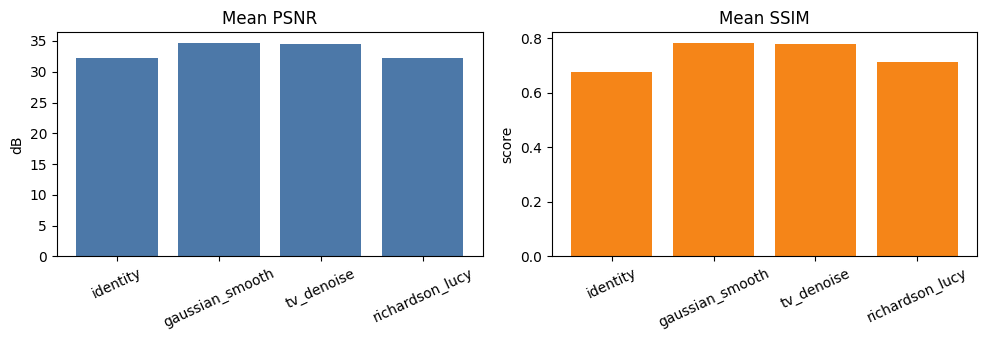

In [5]:
method_order = list(METHODS)
mean_metrics = reconstruction_manifest.groupby("method")[["psnr", "ssim"]].mean().loc[method_order]

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

axes[0].bar(mean_metrics.index, mean_metrics["psnr"], color="#4C78A8")
axes[0].set_title("Mean PSNR")
axes[0].set_ylabel("dB")
axes[0].tick_params(axis="x", rotation=25)

axes[1].bar(mean_metrics.index, mean_metrics["ssim"], color="#F58518")
axes[1].set_title("Mean SSIM")
axes[1].set_ylabel("score")
axes[1].tick_params(axis="x", rotation=25)

plt.tight_layout()


## Preview Reconstructions

Each row shows a galaxy. The columns compare the clean target, degraded observation, and each reconstruction method.


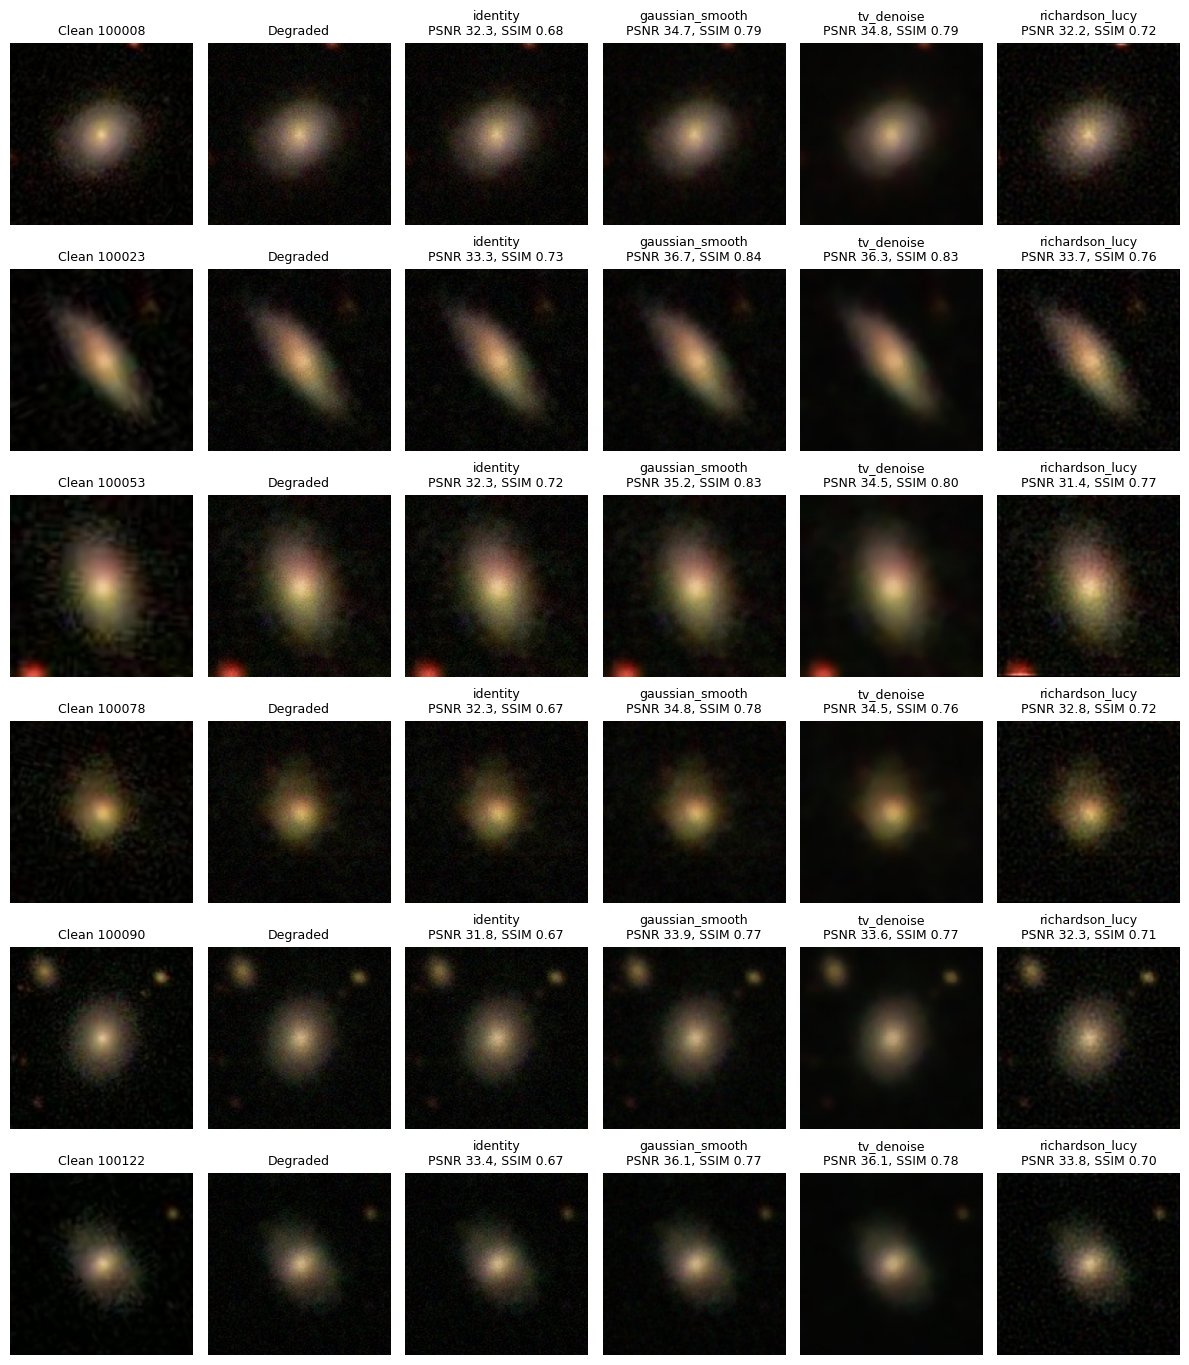

In [6]:
sample_ids = reconstruction_manifest["GalaxyID"].drop_duplicates().head(6).tolist()
method_order = list(METHODS)

fig, axes = plt.subplots(len(sample_ids), len(method_order) + 2, figsize=(12, 2.3 * len(sample_ids)))

for row_index, galaxy_id in enumerate(sample_ids):
    rows = reconstruction_manifest[reconstruction_manifest["GalaxyID"] == galaxy_id].set_index("method")
    first = rows.iloc[0]
    clean = load_rgb_float(PROJECT_ROOT / first["clean_path"])
    degraded = load_rgb_float(PROJECT_ROOT / first["degraded_path"])

    axes[row_index, 0].imshow(clean)
    axes[row_index, 0].set_title(f"Clean {galaxy_id}", fontsize=9)
    axes[row_index, 0].axis("off")

    axes[row_index, 1].imshow(degraded)
    axes[row_index, 1].set_title("Degraded", fontsize=9)
    axes[row_index, 1].axis("off")

    for col_index, method in enumerate(method_order, start=2):
        method_row = rows.loc[method]
        reconstructed = load_rgb_float(PROJECT_ROOT / method_row["reconstructed_path"])
        axes[row_index, col_index].imshow(reconstructed)
        axes[row_index, col_index].set_title(
            f"{method}\nPSNR {method_row['psnr']:.1f}, SSIM {method_row['ssim']:.2f}",
            fontsize=9,
        )
        axes[row_index, col_index].axis("off")

plt.tight_layout()


## Residual Comparison

Residuals are amplified by 4x. Darker residuals mean the reconstruction is closer to the clean target.


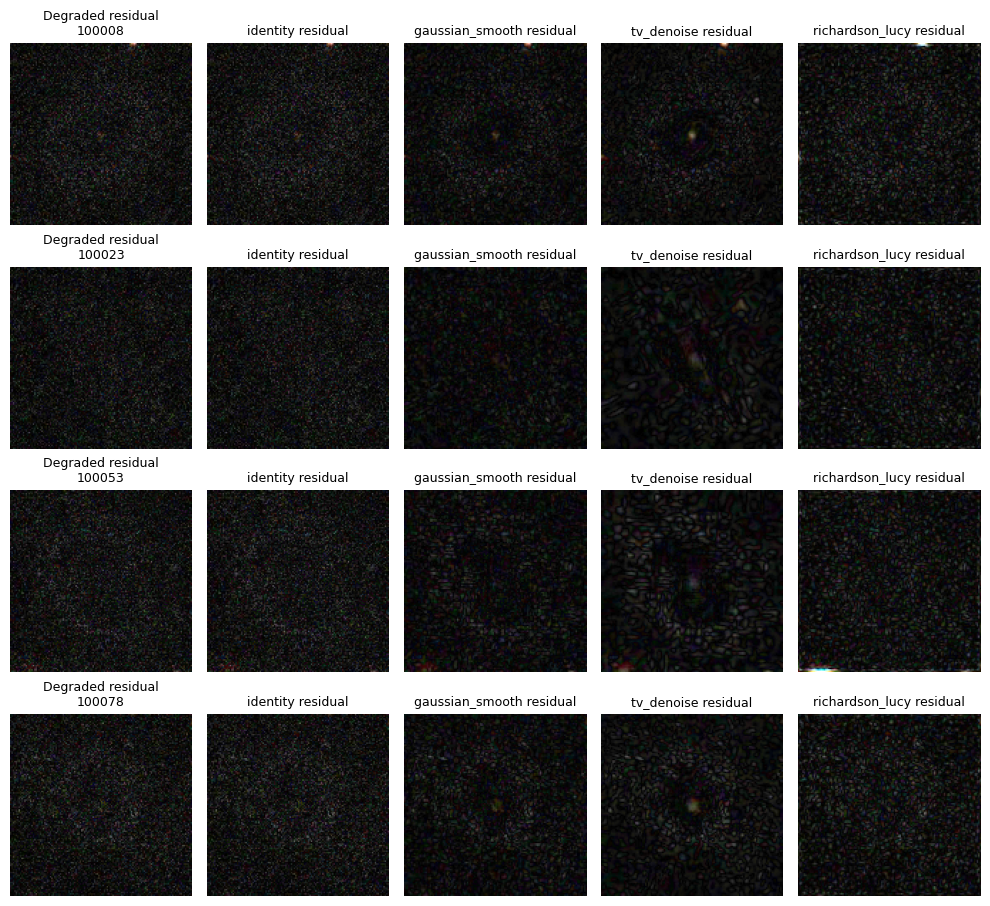

In [7]:
sample_ids = reconstruction_manifest["GalaxyID"].drop_duplicates().head(4).tolist()
method_order = list(METHODS)

fig, axes = plt.subplots(len(sample_ids), len(method_order) + 1, figsize=(10, 2.3 * len(sample_ids)))

for row_index, galaxy_id in enumerate(sample_ids):
    rows = reconstruction_manifest[reconstruction_manifest["GalaxyID"] == galaxy_id].set_index("method")
    first = rows.iloc[0]
    clean = load_rgb_float(PROJECT_ROOT / first["clean_path"])
    degraded = load_rgb_float(PROJECT_ROOT / first["degraded_path"])

    degraded_residual = np.clip(np.abs(clean - degraded) * 4.0, 0.0, 1.0)
    axes[row_index, 0].imshow(degraded_residual)
    axes[row_index, 0].set_title(f"Degraded residual\n{galaxy_id}", fontsize=9)
    axes[row_index, 0].axis("off")

    for col_index, method in enumerate(method_order, start=1):
        reconstructed = load_rgb_float(PROJECT_ROOT / rows.loc[method, "reconstructed_path"])
        residual = np.clip(np.abs(clean - reconstructed) * 4.0, 0.0, 1.0)
        axes[row_index, col_index].imshow(residual)
        axes[row_index, col_index].set_title(f"{method} residual", fontsize=9)
        axes[row_index, col_index].axis("off")

plt.tight_layout()


## Per-Image Improvement

This shows how much each method improves over the degraded-input baseline for the same galaxy.


In [8]:
baseline = reconstruction_manifest[reconstruction_manifest["method"] == "identity"][["GalaxyID", "psnr", "ssim"]]
baseline = baseline.rename(columns={"psnr": "identity_psnr", "ssim": "identity_ssim"})

improvement = reconstruction_manifest.merge(baseline, on="GalaxyID", validate="many_to_one")
improvement["delta_psnr"] = improvement["psnr"] - improvement["identity_psnr"]
improvement["delta_ssim"] = improvement["ssim"] - improvement["identity_ssim"]

display(
    improvement
    .groupby("method")[["delta_psnr", "delta_ssim"]]
    .mean()
    .loc[method_order]
    .round(4)
)


,delta_psnr,delta_ssim
method,,
identity,0.0000,0.0000
gaussian_smooth,2.3949,0.1058
tv_denoise,2.1855,0.1022
richardson_lucy,0.0147,0.0354


## Output Summary

These classical baselines give us a reference point for the next stage: a learned reconstruction model such as a small U-Net or convolutional autoencoder.


In [9]:
summary_path = RECONSTRUCTED_DIR / "summary.json"
print(summary_path.read_text())


{
  "config": {
    "project_root": "/home/vm/dev/Project (Computational Imaging + Physics Applications of AI)/galaxy-zoo-project",
    "degraded_manifest_path": "/home/vm/dev/Project (Computational Imaging + Physics Applications of AI)/galaxy-zoo-project/data/degraded/galaxy_zoo_128_moderate/manifest.csv",
    "output_dir": "/home/vm/dev/Project (Computational Imaging + Physics Applications of AI)/galaxy-zoo-project/data/reconstructed/galaxy_zoo_128_baselines",
    "methods": [
      "identity",
      "gaussian_smooth",
      "tv_denoise",
      "richardson_lucy"
    ],
    "limit": 32,
    "smooth_sigma": 0.6,
    "tv_weight": 0.06,
    "unsharp_radius": 1.0,
    "unsharp_amount": 1.2,
    "rl_sigma": 1.2,
    "rl_iterations": 12,
    "overwrite": true
  },
  "num_input_images": 32,
  "num_reconstructed_images": 128,
  "manifest_path": "data/reconstructed/galaxy_zoo_128_baselines/manifest.csv",
  "metric_summary": {
    "gaussian_smooth": {
      "psnr": 34.66862398940311,
      "ssi